# Przekształcenia punktowe

W trakcie niniejszego ćwiczenia zapoznamy się z podstawowymi operacjami punktowymi (bezkontekstowymi) przeprowadzanymi na obrazach cyfrowych:
- typu LUT (operacja jednoargumentowa),
- arytmetycznymi (operacje dwuargumentowe): dodawanie, odejmowanie, mnożenie, dzielenie,
- logicznymi (operacje jedno i dwuargumentowe): AND, OR, XOR, NOT.

Na początku zaimportuj potrzebne biblioteki.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

## Operacja LUT

**Operacja LUT** polega na przekształcaniu wartości poszczególnych pikseli obrazu przy użyciu z góry przygotowanych tabel przekodowań (tabel korekcji).

W przetwarzaniu obrazów najczęściej wykorzystuje się następujące funkcje:
- typu kwadratowa, pierwiastek kwadratowy
- typu logarytm, odwrócony logarytm
- typu wykładnicza,
- inne (np. piłokształtna).

W tym zadaniu zostały dla Państwa przygotowane tablice przekodowania.
Proszę pobrać je z githuba `https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py` (można użyć znanego polecenia !wget), a następnie zaimportować je poleceniem `import lut`.
Od tego momentu można się do nich odwoływać w następujący sposób: `lut.log` itd.

In [2]:
import lut


ModuleNotFoundError: No module named 'lut'

Wyświetl przykładowe przekodowanie wykorzystując funkcję `plt.plot(lut.kwadratowa)`.

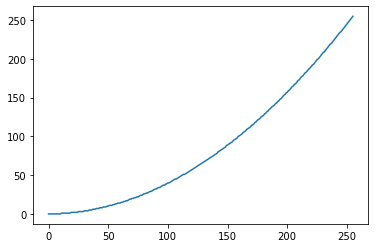

In [ ]:
plt.plot(lut.kwadratowa)

Wybierz jeden z obrazów: _lena.bmp_ lub _jet.bmp_ (w razie potrzeby pobierz go z githuba):
- https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
- https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp

Wczytaj go i wyświetl.

In [ ]:
lena=requests.get('https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp')
jet=requests.get('https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp')
open('lena.bmp', 'wb').write(lena.content)
open('jet.bmp', 'wb').write(jet.content)

66616

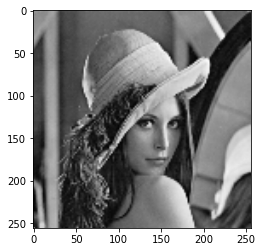

In [ ]:
l=plt.imread('lena.bmp')
plt.imshow(l)
plt.gray()

Na wybranym obrazie wykonaj operację LUT.
Służy do tego funkcja `cv2.LUT` przyjmująca dwa argumenty: obraz oraz tablicę przekodowania.
Wybierz dowolną z zaimportowanych tablic i wyświetl wynikowy obraz.

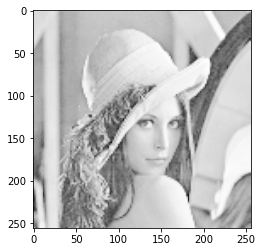

In [ ]:
llut=cv2.LUT(l,lut.log)
plt.imshow(llut)

Aby lepiej zobaczyć w jaki sposób działają różne przekodowania LUT, skonstruujemy funkcję, która jako argumenty pobierać będzie obrazek oryginalny oraz tablicę przekodowania, a następnie na wspólnym rysunku będzie wyświetlać: funkcję, obraz wejściowy oraz wynik przekodowania.

Przypomnienie składni tworzenia funkcji w pythonie:
```{python}
  def nazwa_funkcji(para, metry):
  	# cialo funkcji
```

  - Stwórz nową funkcję i nazwij ją LUT.
  - Funkcja powinna przyjmować dwa parametry: obraz oraz tablicę przekodowania.
  - W ciele funkcji wykonaj przekodowanie LUT, podobnie jak wcześniej w przykładzie.
  - Funkcja powinna wyświetlić wykres składający się z 3 umieszczonych obok siebie pól: wykres przekodowania, obraz oryginalny oraz obraz przekształcony.
    Każdy z wykresów powinien być podpisany.
    _(W razie problemów można przypomnieć sobie te zagadnienia z laboratorium wprowadzającego)_
  - Jeśli wykres przekodowania jest zbyt rozciągnięty, można go wyrównać, np. `ax2.set_aspect('equal')`.

In [ ]:
def LUT(picture,tab):
    lut_picture=cv2.LUT(picture,tab)
    fig, (ax1,ax2,ax3) = plt.subplots(1, 3)
    ax1.plot(tab)
    ax2.imshow(picture)
    ax3.imshow(lut_picture)
    ax1.set_title('wykres przekodowania')
    ax2.set_title('obraz oryginalny')
    ax3.set_title('obraz przekształcony')


Wywołaj przygotowaną funkcję dla każdego z przekształceń.
W wyniku powinno powstać 7 wykresów.

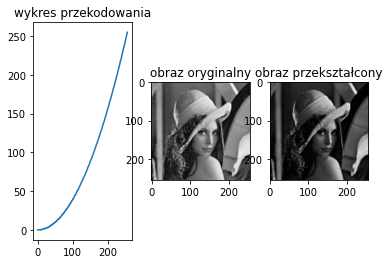

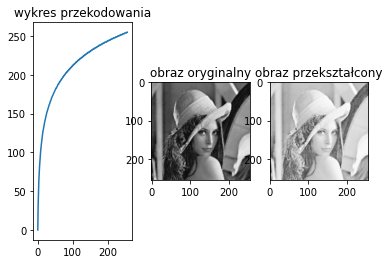

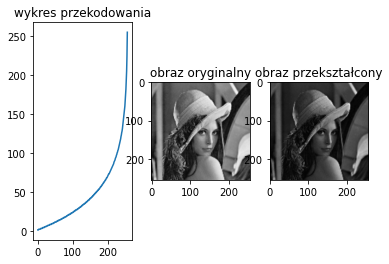

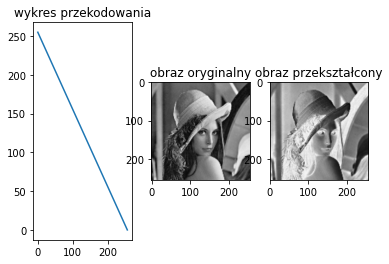

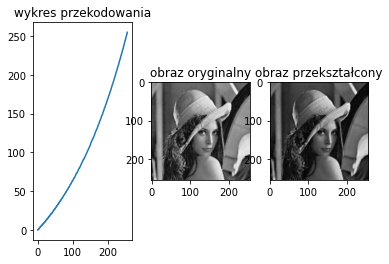

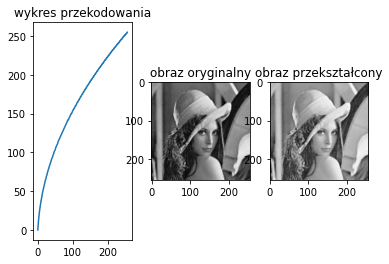

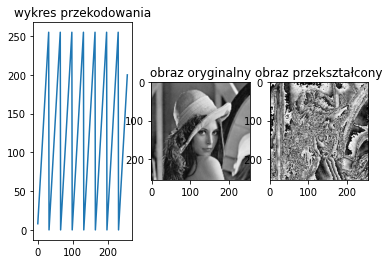

In [ ]:
LUT(l,lut.kwadratowa)
LUT(l,lut.log)
LUT(l,lut.odwlog)
LUT(l,lut.odwrotna)
LUT(l,lut.wykladnicza)
LUT(l,lut.pierwiastkowa)
LUT(l,lut.pila)

## Operacja arytmetyczne

### Dodawanie

Wczytaj dwa obrazy _lena.bmp_ i _jet.bmp_ i wyświetl je.

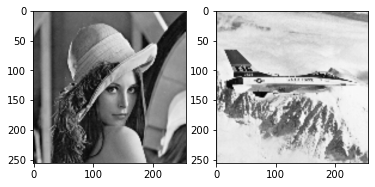

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2)

l=plt.imread('lena.bmp')
ax1.imshow(l)
j=plt.imread('jet.bmp')
ax2.imshow(j)

Dodaj obrazy _lena_ i _jet_, wykorzystaj funkcję `cv2.add`.
Uzyskany wynik wyświetl.

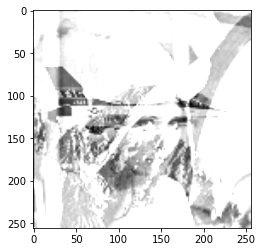

In [ ]:
plt.imshow(cv2.add(j,l))

Czy wynik sumowania jest satysfakcjonujący?
Co może niekorzystnie wpływać na rezultat operacji?
Spróbuj wykonać dodawanie ponownie wykorzystując typ uint16 (`jet.astype('uint16')`).
Wynikowy obraz należy przeskalować do zakresu 0-255, zamienić na typ uint8 i wyświetlić. _
Uwaga: operacja ta jest użyteczna w przypadku, gdy dane do wyświetlenia wykraczają poza zakres 0-255, w przeciwnym przypadku jej wykorzystanie może zniekształcić wyniki._

Text(0.5, 1.0, 'previuos in uint8')

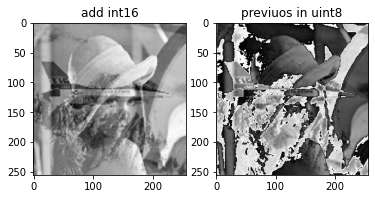

In [ ]:
new=cv2.add(l.astype('int16'),j.astype('int16'))
fig,(ax1,ax2)=plt.subplots(1,2)
ax1.imshow(new)
ax1.set_title('add int16')
ax2.imshow(new.astype('uint8'))
ax2.set_title('previuos in uint8')

### Kombinacja liniowa

Do wykonywania operacji kombinacji liniowej służy funkcja `cv2.addWeighted`.
Zapoznaj się z dokumentacją tej funkcji i przetestuj kilka kombinacji liniowych obrazów _lena_ i _jet_.
Wyświetl wynik dowolnej z nich.

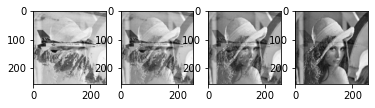

In [ ]:
w1=cv2.addWeighted(l,0.2,j,0.8,0)
w2=cv2.addWeighted(l,0.4,j,0.6,0)
w3=cv2.addWeighted(l,0.6,j,0.4,0)
w4=cv2.addWeighted(l,0.8,j,0.2,0)
fig,(ax1,ax2,ax3,ax4)=plt.subplots(1,4)

ax1.imshow(w1)
ax2.imshow(w2)
ax3.imshow(w3)
ax4.imshow(w4)

### Odejmowanie

Wykorzystując funkcję `cv2.subtract` odejmij obrazy _lena_ i _jet_.

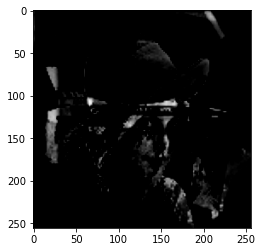

In [ ]:
plt.imshow(cv2.subtract(l,j))

Czy wynik odejmowania jest satysfakcjonujący?
Co może niekorzystnie wpływać na rezultat operacji?
Często zamiast zwykłego odejmowania wykorzystuje się operację wartość bezwzględna z różnicy (pozwala to między innymi uniknąć pokazanych powyżej problemów).
Zamień typ obrazów _lena_ i _jet_ z uint8 na **int16**, odejmij je od siebie, a następnie wykorzystując funkcję `np.abs` wykonaj operację wartość bezwzględna z różnicy.
Wyświetl ten obraz.
Zastanów się, dlaczego ta zmiana poprawia wynik odejmowania?

Text(0.5, 1.0, 'after abs()')

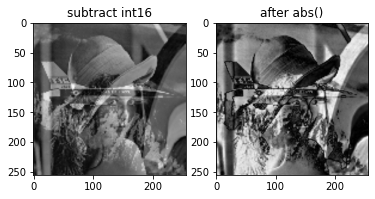

In [ ]:
new=cv2.subtract(l.astype('int16'),j.astype('int16'))
fig,(ax1,ax2)=plt.subplots(1,2)
ax1.imshow(new)
ax1.set_title('subtract int16')
nabs=np.abs(new)
ax2.imshow(nabs)
ax2.set_title('after abs()')

### Mnożenie

Mnożenie dwóch obrazów pozwala wykonać funkcja `cv2.multiply`.
Wykonaj mnożenie obrazów _lena_ i _jet_.
Czy wynik takiej operacji zawiera jakąś istotną informację?
Dlaczego?

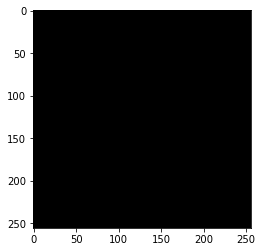

In [ ]:
plt.imshow(cv2.multiply(l,j))

Mnożenie częściej wykorzystuje się jako:
  + mnożenie przez stałą $-$ co powoduje ogólne rozjaśnienie albo ściemnienie obrazu,
  + mnożenie przez maskę $-$ czyli obraz binarny.

Wczytaj maskę _kolo.bmp_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp).
Przemnóż wybrany obraz przez maskę i wyświetl wynik.
Mnożenie przez maskę można zrealizować za pomocą funkcji `cv2.multiply`, ale maskę należy należy najpierw przekształcić z zakresu 0-255 do 0-1, na przykład `(maska).astype('bool').astype('uint8')`.

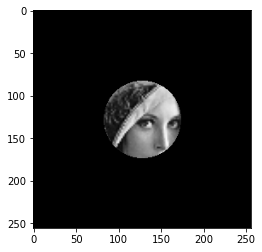

In [ ]:
mask=requests.get('https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp')
open('maska.bmp', 'wb').write(mask.content)
maska=plt.imread('maska.bmp')
m=maska.astype('bool').astype('uint8')
plt.imshow(cv2.multiply(l,m))

### Negatyw

Negatyw obrazu uzyskuje się za pomocą funkcji `cv2.bitwise_not(img)`
Negatyw obrazu można również uzyskać wykorzystując przekodowanie LUT.
Można w tym celu posłużyć się przygotowaną wcześniej tablicą `lut.odwrotna`.
Przetestuj działanie tych funkcji i wykonaj negatyw obrazu _lena_ dowolnym sposobem.

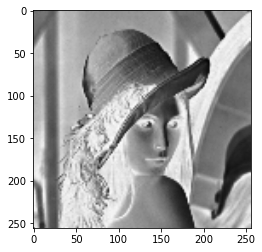

In [ ]:
plt.imshow(cv2.bitwise_not(l))

## Operacje logiczne

Na poszczególnych punktach obrazu (najczęściej binarnego $-$ czyli składającego się z dwóch kolorów: czarnego i białego) można wykonywać operacje logiczne: NOT, AND, OR, XOR itp.
Wczytaj dwa obrazy: _kolo.bmp_ i _kwadrat.bmp_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp), następnie wyświetl je.

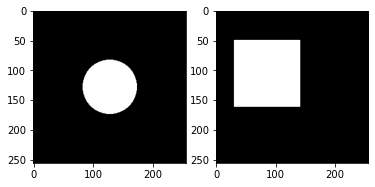

In [ ]:
kwadr=requests.get('https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp')
open('kwadrat.bmp', 'wb').write(kwadr.content)
kw=plt.imread('kwadrat.bmp')
kw=kw.astype('bool').astype('uint8')
fig,(ax1,ax2)=plt.subplots(1,2)

ax1.imshow(m)
ax2.imshow(kw)

Na wczytanych obrazach wykonaj wybrane operacje logiczne: NOT (operator `~`), AND (`&`), OR (`|`), XOR (`^`).
Operator `~` jest jednoargumentowy, wszystkie pozostałe są dwuargumentowe.
Alternatywnym sposobem jest wykorzystanie funkcji z biblioteki opencv: `cv2.bitwise_not`, `cv2.bitwise_and`, `cv2.bitwise_or`, `cv2.bitwise_xor`.
Wyświetl rezultaty.

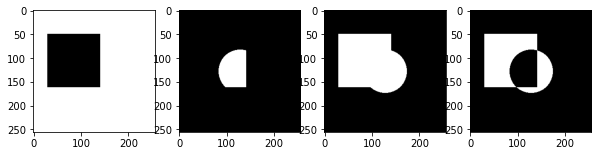

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(10,10))
ax[0].imshow(~kw)
ax[1].imshow(m&kw)
ax[2].imshow(m|kw)
ax[3].imshow(m^kw)